In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pymc as pm
import arviz as az
import pytensor.tensor as pt
import pytensor
import japanize_matplotlib

,cumulative_confirmed,daily_new,t_day
2020-01-22,444,444.0,0
2020-01-23,444,0.0,1
2020-01-24,549,105.0,2
2020-01-25,761,212.0,3
2020-01-26,1058,297.0,4


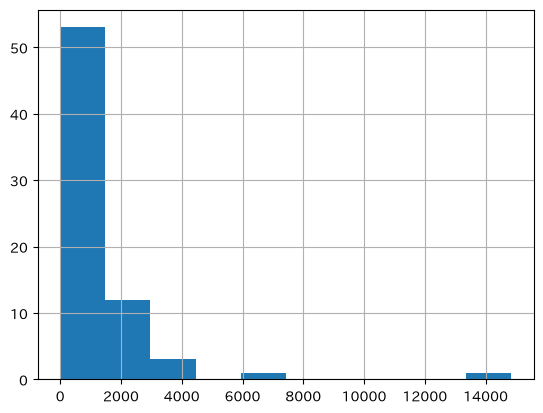

In [2]:
df = pd.read_csv("../data/hubei_covid_seir.csv", index_col=0, parse_dates=True)
df["daily_new"].hist()
df.head()

In [3]:
daily_new_obs = df["daily_new"].values
n_days = len(daily_new_obs)
N_pop = 6e7

n_steps_per_day = 50
dt = 1.0/n_steps_per_day
total_steps = n_steps_per_day * (n_days-1)

In [4]:
with pm.Model() as seir_model_v0:
    sigma = pm.Gamma("sigma", alpha=50, beta=50/0.2)
    gamma = pm.Gamma("gamma", alpha=50, beta=50/0.14)
    R0_repro = pm.Gamma("R0_repro", mu=3.5, sigma=0.16)
    beta = pm.Deterministic("beta", R0_repro * gamma)

    initial_obs = float(daily_new_obs[0])
    E0 = pm.Deterministic("E0", pt.as_tensor_variable(initial_obs / sigma, dtype="float64"))
    I0 = pt.as_tensor_variable(initial_obs, dtype="float64")
    R_init = pt.as_tensor_variable(0.0, dtype="float64")


    def euler_step(E_prev, I_prev, R_prev, beta, sigma, gamma, N, dt):
        S_prev = N - E_prev - I_prev - R_prev
        dE = (beta * S_prev * I_prev / N - sigma * E_prev) * dt 
        dI = (sigma * E_prev - gamma * I_prev) * dt
        dR = (gamma * I_prev) * dt
        E_new = pt.clip(E_prev + dE, 0.0, N)
        I_new = pt.clip(I_prev + dI, 0.0, N)
        R_new = pt.clip(R_prev + dR, 0.0, N)
        return E_new, I_new, R_new

    (E_path, I_path, R_path), _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[E0, I0, R_init],
        non_sequences=[beta, sigma, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = np.arange(n_steps_per_day-1, total_steps, n_steps_per_day)
    E_pred = pt.concatenate([[E0], E_path[idx]])

    daily_new_pred = sigma * E_pred
    pm.Deterministic("daily_new_pred", daily_new_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=1.0, beta=1.0/10)
    rate_param = pm.Deterministic("rate_param", alpha_conc / pt.clip(daily_new_pred, 1.0, N_pop))
    pm.Gamma("obs", alpha=alpha_conc,beta=rate_param, observed=daily_new_obs)
    

/tmp/ipykernel_3528/1010323726.py:23: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (E_path, I_path, R_path), _ = pytensor.scan(


/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/pytensor/link/c/cmodule.py:2978: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function.
For more options and details see https://pytensor.readthedocs.io/en/latest/troubleshooting.html#how-do-i-configure-test-my-blas-library
  warnings.warn(


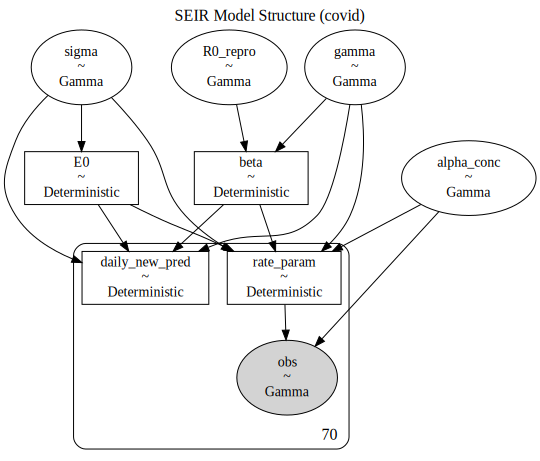

In [5]:
g_v0 = pm.model_to_graphviz(seir_model_v0)

g_v0.graph_attr.update(
    label="SEIR Model Structure (covid)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

# 3. 指定したファイル名で保存
g_v0.render(filename="../models/seir_model_graph", format="png", cleanup=True)
g_v0

In [6]:
with seir_model_v0:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

/home/manaty/baysian-epidemiological-models/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Sampling: [R0_repro, alpha_conc, gamma, obs, sigma]


In [7]:
daily_new_pred_prior = prior.prior["daily_new_pred"].values.reshape(-1, n_days)

daily_new_pred の統計:
  最小値: 372.44929233678107
  最大値: 2571305.6511765784
  99percentile: 2190216.548656889
  実データ最大値: 14840.0

R0_repro: 平均= 3.459967879858178 範囲=[ 3.08938577891565 , 3.947081119157122 ]
beta: 平均= 0.487628071203298 範囲=[ 0.28965899115831156 , 0.7184686581825072 ]


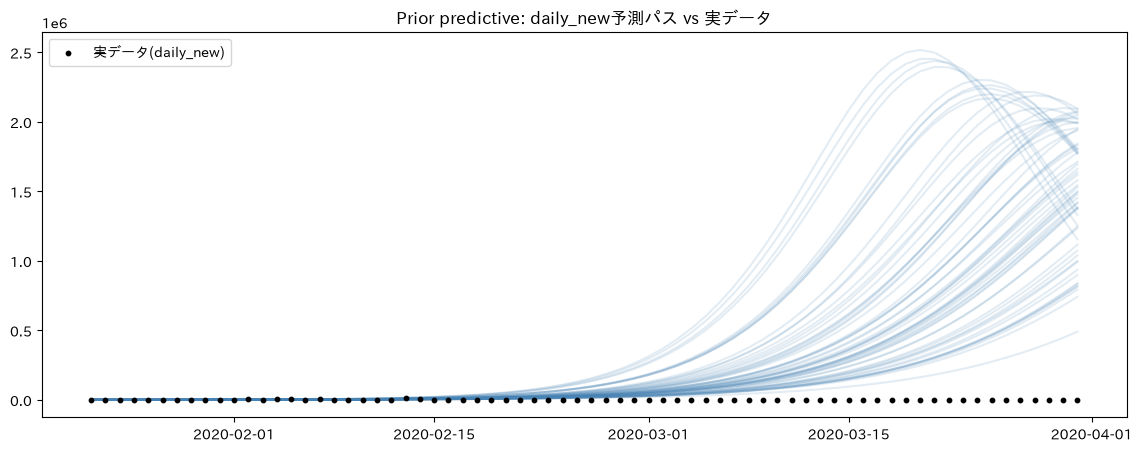

In [9]:
fig, ax = plt.subplots(figsize=(14, 5))
for i in range(60):
    ax.plot(df.index, daily_new_pred_prior[i], color="steelblue", alpha=0.15)
ax.scatter(df.index, daily_new_obs, color="black", s=10, zorder=5, label="実データ(daily_new)")
ax.legend()
ax.set_title("Prior predictive: daily_new予測パス vs 実データ")
plt.savefig("../img/seir_prior_check_v0.png", dpi=100)

print("daily_new_pred の統計:")
print("  最小値:", daily_new_pred_prior.min())
print("  最大値:", daily_new_pred_prior.max())
print("  99percentile:", np.percentile(daily_new_pred_prior, 99))
print("  実データ最大値:", daily_new_obs.max())

R0_prior = prior.prior["R0_repro"].values.flatten()
print("\nR0_repro: 平均=", R0_prior.mean(), "範囲=[", R0_prior.min(), ",", R0_prior.max(), "]")

beta_prior = prior.prior["beta"].values.flatten()
print("beta: 平均=", beta_prior.mean(), "範囲=[", beta_prior.min(), ",", beta_prior.max(), "]")

In [10]:
cum = df["cumulative_confirmed"].values

print(df[["cumulative_confirmed"]].head(15))

            cumulative_confirmed
2020-01-22                   444
2020-01-23                   444
2020-01-24                   549
2020-01-25                   761
2020-01-26                  1058
2020-01-27                  1423
2020-01-28                  3554
2020-01-29                  3554
2020-01-30                  4903
2020-01-31                  5806
2020-02-01                  7153
2020-02-02                 11177
2020-02-03                 13522
2020-02-04                 16678
2020-02-05                 19665


In [11]:
#感染期間と潜伏期間をそれぞれ2日ほどに減らす
with pm.Model() as seir_model_v1:
    sigma = pm.Gamma("sigma", alpha=50, beta=50/0.5)
    gamma = pm.Gamma("gamma", alpha=50, beta=50/0.5)
    R0_repro = pm.Gamma("R0_repro", mu=2, sigma=0.16)
    beta = pm.Deterministic("beta", R0_repro * gamma)

    initial_obs = float(daily_new_obs[0])
    E0 = pm.Deterministic("E0", pt.as_tensor_variable(initial_obs / sigma, dtype="float64"))
    I0 = pt.as_tensor_variable(initial_obs, dtype="float64")
    R_init = pt.as_tensor_variable(0.0, dtype="float64")


    def euler_step(E_prev, I_prev, R_prev, beta, sigma, gamma, N, dt):
        S_prev = N - E_prev - I_prev - R_prev
        dE = (beta * S_prev * I_prev / N - sigma * E_prev) * dt 
        dI = (sigma * E_prev - gamma * I_prev) * dt
        dR = (gamma * I_prev) * dt
        E_new = pt.clip(E_prev + dE, 0.0, N)
        I_new = pt.clip(I_prev + dI, 0.0, N)
        R_new = pt.clip(R_prev + dR, 0.0, N)
        return E_new, I_new, R_new

    (E_path, I_path, R_path), _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[E0, I0, R_init],
        non_sequences=[beta, sigma, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = np.arange(n_steps_per_day-1, total_steps, n_steps_per_day)
    E_pred = pt.concatenate([[E0], E_path[idx]])

    daily_new_pred = sigma * E_pred
    pm.Deterministic("daily_new_pred", daily_new_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=1.0, beta=1.0/10)
    rate_param = pm.Deterministic("rate_param", alpha_conc / pt.clip(daily_new_pred, 1.0, N_pop))
    pm.Gamma("obs", alpha=alpha_conc,beta=rate_param, observed=daily_new_obs)
    

/tmp/ipykernel_3528/1270510595.py:24: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (E_path, I_path, R_path), _ = pytensor.scan(


In [12]:
with seir_model_v1:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

Sampling: [R0_repro, alpha_conc, gamma, obs, sigma]


In [13]:
daily_new_pred_prior = prior.prior["daily_new_pred"].values.reshape(-1, n_days)

daily_new_pred の統計:
  最小値: 408.3248017476465
  最大値: 3677308.712240719
  99percentile: 2736345.4695124193
  実データ最大値: 14840.0

R0_repro: 平均= 1.9599105010278086 範囲=[ 1.6003036685606917 , 2.4587549688422925 ]
beta: 平均= 0.9865131291918927 範囲=[ 0.5744551562945807 , 1.4322369857141874 ]


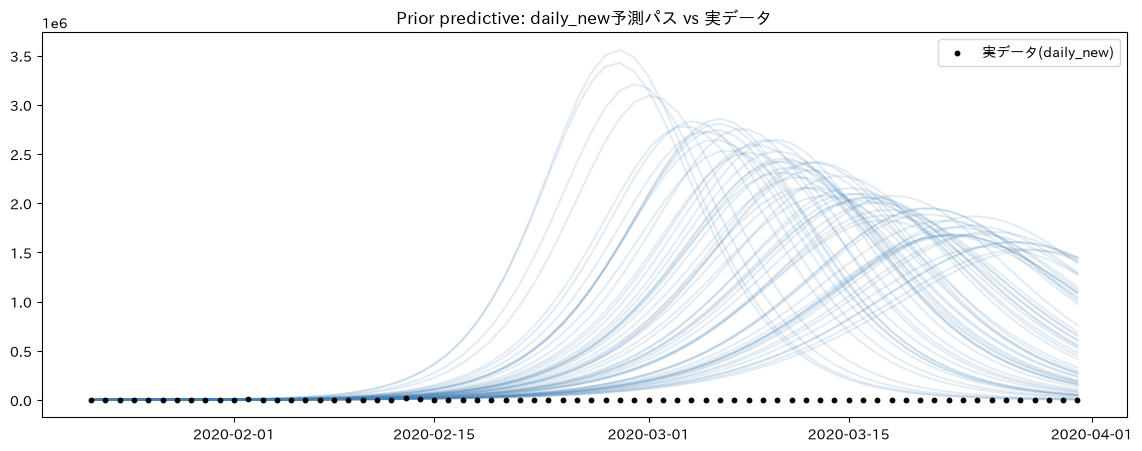

In [15]:
fig, ax = plt.subplots(figsize=(14, 5))
for i in range(60):
    ax.plot(df.index, daily_new_pred_prior[i], color="steelblue", alpha=0.15)
ax.scatter(df.index, daily_new_obs, color="black", s=10, zorder=5, label="実データ(daily_new)")
ax.legend()
ax.set_title("Prior predictive: daily_new予測パス vs 実データ")
plt.savefig("../img/seir_prior_check_v1.png", dpi=100)

print("daily_new_pred の統計:")
print("  最小値:", daily_new_pred_prior.min())
print("  最大値:", daily_new_pred_prior.max())
print("  99percentile:", np.percentile(daily_new_pred_prior, 99))
print("  実データ最大値:", daily_new_obs.max())

R0_prior = prior.prior["R0_repro"].values.flatten()
print("\nR0_repro: 平均=", R0_prior.mean(), "範囲=[", R0_prior.min(), ",", R0_prior.max(), "]")

beta_prior = prior.prior["beta"].values.flatten()
print("beta: 平均=", beta_prior.mean(), "範囲=[", beta_prior.min(), ",", beta_prior.max(), "]")

In [16]:
#E0とI0を見直す
with pm.Model() as seir_model_v2:
    
    sigma = pm.Gamma("sigma", alpha=50, beta=50/0.5)
    gamma = pm.Gamma("gamma", alpha=50, beta=50/0.5)
    R0_repro = pm.Gamma("R0_repro", mu=2, sigma=0.16)
    beta = pm.Deterministic("beta", R0_repro * gamma)

    E0_dist = pm.LogNormal("E0_dist", mu=np.log(10000), sigma=0.5)
    E0 = pm.Deterministic("E0", pt.as_tensor_variable(E0_dist, dtype="float64"))
    I0 = pm.Deterministic("I0", 0.1 * E0)
    R_init = pt.as_tensor_variable(0.0, dtype="float64")


    def euler_step(E_prev, I_prev, R_prev, beta, sigma, gamma, N, dt):
        S_prev = N - E_prev - I_prev - R_prev
        dE = (beta * S_prev * I_prev / N - sigma * E_prev) * dt 
        dI = (sigma * E_prev - gamma * I_prev) * dt
        dR = (gamma * I_prev) * dt
        E_new = pt.clip(E_prev + dE, 0.0, N)
        I_new = pt.clip(I_prev + dI, 0.0, N)
        R_new = pt.clip(R_prev + dR, 0.0, N)
        return E_new, I_new, R_new

    (E_path, I_path, R_path), _ = pytensor.scan(
        fn=euler_step,
        outputs_info=[E0, I0, R_init],
        non_sequences=[beta, sigma, gamma, N_pop, dt],
        n_steps=total_steps
    )

    idx = np.arange(n_steps_per_day-1, total_steps, n_steps_per_day)
    E_pred = pt.concatenate([[E0], E_path[idx]])

    daily_new_pred = sigma * E_pred
    pm.Deterministic("daily_new_pred", daily_new_pred)

    alpha_conc = pm.Gamma("alpha_conc", alpha=1.0, beta=1.0/10)
    rate_param = pm.Deterministic("rate_param", alpha_conc / pt.clip(daily_new_pred, 1.0, N_pop))
    pm.Gamma("obs", alpha=alpha_conc,beta=rate_param, observed=daily_new_obs)
    

/tmp/ipykernel_3528/997557410.py:25: DeprecationWarning: Scan return signature will change. Updates dict will not be returned, only the first argument. Pass `return_updates=False` to conform to the new API and avoid this warning
  (E_path, I_path, R_path), _ = pytensor.scan(


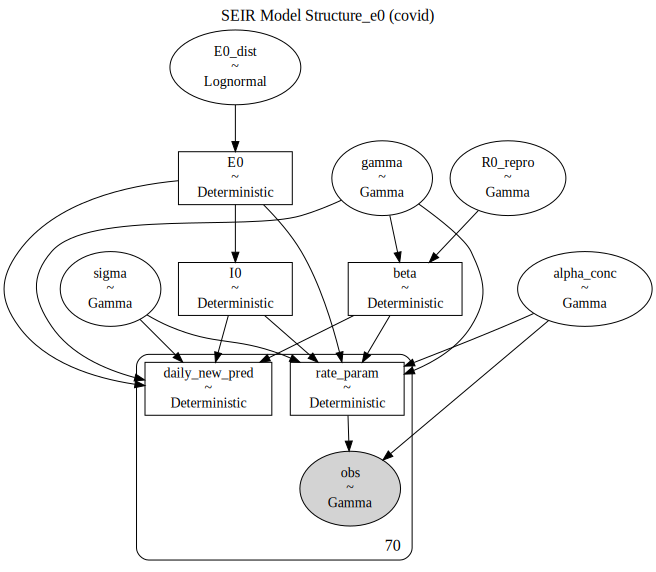

In [18]:
g_v2 = pm.model_to_graphviz(seir_model_v2)

g_v2.graph_attr.update(
    label="SEIR Model Structure_e0 (covid)",  # ここに好きなタイトルを入れる
    labelloc="t",                        # タイトルの位置を上に配置 (top)
    fontsize="16"                        # フォントサイズ
)

# 3. 指定したファイル名で保存
g_v2.render(filename="../models/seir_model_graph_e0", format="png", cleanup=True)
g_v2

Sampling: [E0_dist, R0_repro, alpha_conc, gamma, obs, sigma]


daily_new_pred 最大値: 3693140.3922425183
99percentile: 2737005.422782615
E0: 中央値= 9900.714865162046 範囲=[ 1760.072694692535 , 33200.88202237693 ]


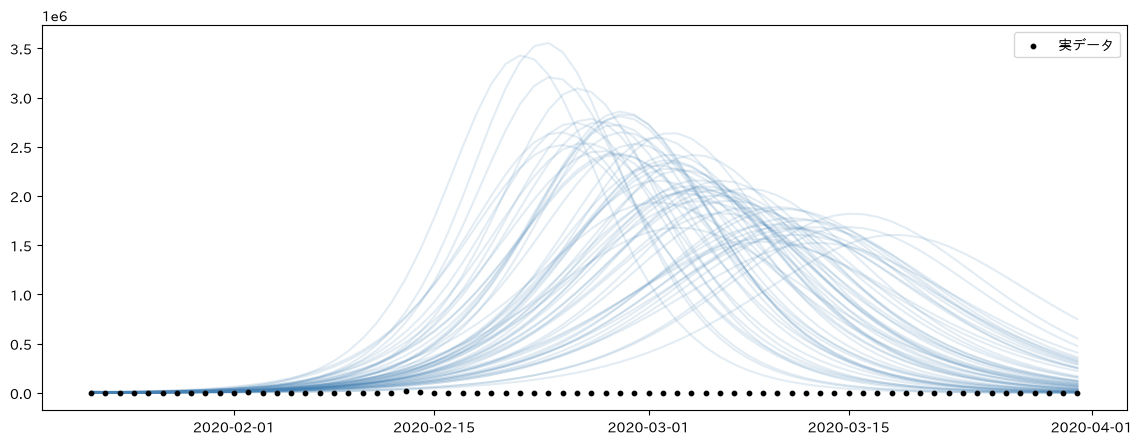

In [19]:
with seir_model_v2:
    prior = pm.sample_prior_predictive(draws=300, random_seed=42)

daily_new_pred_prior = prior.prior["daily_new_pred"].values.reshape(-1, n_days)

fig, ax = plt.subplots(figsize=(14, 5))
for i in range(60):
    ax.plot(df.index, daily_new_pred_prior[i], color="steelblue", alpha=0.15)
ax.scatter(df.index, daily_new_obs, color="black", s=10, zorder=5, label="実データ")
ax.legend()
plt.savefig("../img/seir_prior_check_v2.png", dpi=100)

print("daily_new_pred 最大値:", daily_new_pred_prior.max())
print("99percentile:", np.percentile(daily_new_pred_prior, 99))

E0_prior = prior.prior["E0"].values.flatten()
print("E0: 中央値=", np.median(E0_prior), "範囲=[", E0_prior.min(), ",", E0_prior.max(), "]")

# 湖北省COVID-19初期流行(2020) SEIR機構モデル セッションサマリー

## 目的

SIR(Eyam)→SIS(マラリア)→SIRS(インフルエンザ)に続く機構論的モデルの最終弾。**Eコンパートメント(潜伏期)が観測データに直接現れない部分観測系**という、これまでで最も難易度の高い課題に取り組んだ。結果的にモデル構造とデータの不整合という、パラメータ調整では解決不能な壁に行き着いた回となった。

## データ取得

- Hagelloch麻疹アウトブレイク(1861年、個人レベルで潜伏期の推定が可能な理想的データ)を第一候補としたが、R言語パッケージ内にのみ存在しCSV化できず、R環境も無かったため断念。
- 代替として、JHU CSSE COVID-19データリポジトリ(GitHub, raw.githubusercontent.com)から取得。湖北省の2020年1月22日〜3月31日、日次新規感染者数(累計の差分)、70日分。1月末〜2月頭に急激なピーク(最大14,840人/日)を迎え、3月にはほぼ収束する、明確な急拡大パターン。

## モデル構造と設計判断

$$\frac{dS}{dt}=-\beta SI/N,\ \frac{dE}{dt}=\beta SI/N-\sigma E,\ \frac{dI}{dt}=\sigma E-\gamma I,\ \frac{dR}{dt}=\gamma I$$

- 観測モデル: $\text{daily\_new}(t)\approx\sigma E(t)$(SISのincidence≈γIと同型の発想。「潜伏期間中に発症する確率を掛け合わせるべきでは」という提案が出たが、これは$\sigma E$という項自体が既に体現している内容であることを確認)
- 状態変数を$E,I,R$の3つとし$S=N-E-I-R$で導出、独立変数を最小化する設計はSIS/SIRSと一貫。

## パラメータ設計における誤りの修正

これまでのセッションと同型の誤りが再度発生し、その都度修正:
1. $\sigma=0.10$(潜伏期間10日)は妥当な出発点だったが、$\gamma=7.0$は「感染期間7日」を$\gamma$そのものに代入する、$1/\gamma$との取り違え(SISのときと同型)。$\gamma\approx0.14$に修正。
2. `daily_new = dI/dt`という提案は、正味の変化量(増加−減少)であり観測量(新規発症数のみ)とは異なることを指摘。$\sigma E(t)$への対応を確認。
3. 変数名衝突(`R0_repro`を`pm.Gamma("gamma", ...)`と誤命名)、タイプミス(`RO_repro`、`R_new = R_new + dR`という自己参照、`ountputs_info`、`rate_params`)を複数回検出・修正。SIRS同様、命名規則の一貫した確認が必要だった。

## Prior predictive checkでの長期にわたる試行錯誤(このセッションの核心)

### 第一段階: R0中心を1.1に設定 → 立ち上がりが弱すぎる

$R_0\approx1.07$では感染拡大がほぼ横ばいにしかならず、実データの急拡大を再現できないことを確認。

### 第二段階: R0を2.5、3.5と段階的に引き上げ → 規模は暴走するが、立ち上がりのタイミングは改善せず

$R_0$をCOVID-19文献値の上限に近い3.5まで引き上げても、事前予測パスの立ち上がりが3月に集中したままで、実データのピーク(1月末〜2月頭)に追いつかないという、**「R0を上げても解決しない」**という反直感的な結果が得られた。

### 第三段階: σ, γを意図的に速める(世代時間を短縮) → 改善するが依然不十分

潜伏期間・感染期間をともに2日という、医学的に非現実的な水準まで縮めても、立ち上がりは2月中旬〜下旬までしか早まらず、実データの急峻さに届かなかった。

### 第四段階: E0を独立確率変数化(LogNormal、中心1万人)し、観測開始前からの"隠れた流行"を仮定 → それでも変化はごくわずか

$E_0$を機械的な逆算値(888人)から10倍以上(1万人)に引き上げても、立ち上がりのタイミングにほとんど影響しないことを確認。

### 結論: パラメータ調整では解決しない、モデル構造とデータ生成過程の不整合

$R_0$、世代時間、$E_0$という主要な自由度をすべて試し尽くしてもなお実データの急峻な立ち上がりを再現できなかったことから、**「観測データ(daily_new)が真の生物学的感染拡大速度ではなく、検査・報告体制の急速な拡充速度を強く反映している」**という、モデルの生成過程とデータの生成過程そのものが乖離している可能性が高いと判断した。これは非識別性(パラメータ間の情報の混同)とは異なる、より根源的な「モデルの誤設定(misspecification)」の一種であり、パラメータ探索では原理的に解決できない種類の限界であることを確認した。

---

## 主要な学び

1. **「パラメータをどれだけ動かしても解決しない」ことを実際に確認するプロセス自体に価値がある**: R0、世代時間、E0という3つの独立した自由度を、それぞれ大胆に動かして効果がないことを一つずつ実証したことで、「なんとなく合わない」ではなく「モデル構造の限界」という結論に、検証を経て到達できた。
2. **非識別性とモデルの誤設定は、異なる種類の壁である**: これまでのセッション(SVの2-factor、Hawkesのκ/β、SISのR0)で繰り返し遭遇した非識別性は「パラメータの表現力の問題」だったが、今回遭遇したのは「モデルが想定する生成過程と、データが実際に記録している生成過程がそもそも異なる」という、一段深い問題。前者はモデルの再パラメータ化で緩和できたが、後者はパラメータ調整では原理的に解決しない。
3. **観測データが"何を測っているか"を疑うことの重要性**: `daily_new`を疑いなく「真の発症数」として扱っていたが、検査・報告体制という観測プロセス自体にも急激な変化があった可能性を、モデルとデータの不整合という形で初めて具体的に突きつけられた。MSMのラベルスイッチングや点過程の非識別性と同様、「モデルが健全に収束すること」と「モデルが正しい問いに答えていること」は別軸であるという、セッション全体を貫く原則の、最も強い形での再確認となった。
4. **理想的なデータでないと分かった時点で、それ自体を結果として受け止める**: 「データが悪い」という結論は、それに至るまでの体系的な検証(仮説を立てて確かめ、反証したら次の仮説に移る)があってこそ意味を持つ。むやみに「モデルが悪い」「事前分布が悪い」と結論づけず、複数の候補を実際に動かして確かめた上でこの結論に至った点が、これまでのセッション全体で培ってきた診断の型の集大成といえる。

## SIR→SIS→SIRS→SEIRを通じての位置づけ

4つの機構論的モデルを通じ、パラメータのスケール感をデータから逆算する手順は一貫して有効だったが、SEIRでは初めて「逆算しても解決しない」ケースに遭遇した。これは決して失敗ではなく、**機構論的モデリングが持つ本質的な限界(モデルは仮説であり、データの生成過程についての仮定を含む)を、実践を通じて体感できた、意義のある結末**だったと言える。
